In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("/Users/manhhung/Desktop/churn_models_for_telecom_company/data/train_data.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
total_sample = len(df)
print(f"Dataset có {total_sample} bản ghi")
df.info()

Dataset có 2666 bản ghi
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night char

In [7]:
df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [9]:
df.dtypes

State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

# Biverate Analysis and Visualization

In [10]:
df['Churn'].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [16]:
df = pd.read_csv("/Users/manhhung/Desktop/churn_models_for_telecom_company/data/train_data.csv")
df['Churn'] = df['Churn'].astype(int)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [17]:
df.select_dtypes(include='object').columns.tolist()

['State', 'International plan', 'Voice mail plan']

  International plan  Churn  Count      Ratio
0                 No      0   2126  88.731219
1                 No      1    270  11.268781
2                Yes      0    152  56.296296
3                Yes      1    118  43.703704


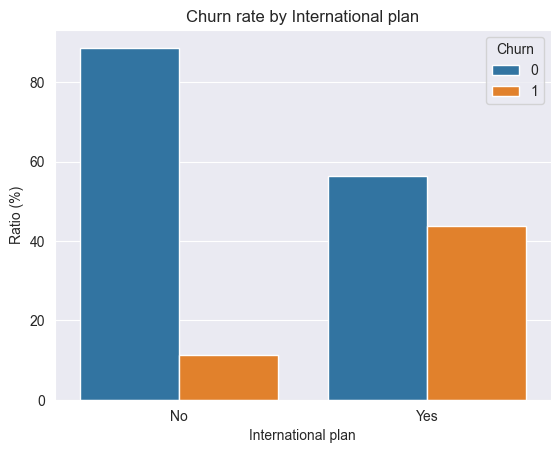

In [32]:
summary = df.groupby('International plan')['Churn'].value_counts().reset_index()
summary.columns = ['International plan', 'Churn', 'Count']
summary['Ratio'] = summary.groupby('International plan')['Count'].transform(lambda x: x / x.sum()) * 100
print(summary)
sns.barplot(data=summary, x='International plan', y='Ratio', hue='Churn')
plt.title('Churn rate by International plan')
plt.ylabel('Ratio (%)')
plt.show()

Nhận xét :
- Số kh k dùng gói quốc tế khá ( 2k3 khách) so với chỉ gần 300 khách dùng
- Với các khách hàng k dùng, tỉ lệ churn khá thấp, chỉ 11%
- Còn với khách dùng thì churn lên tới 43%
- International plan là yếu tố rủi ro cao, công ty cần xem lại chất lượng/giá cả gói quốc tế để giữ chân nhóm này


  Voice mail plan  Churn  Count      Ratio
0              No      0   1610  83.290222
1              No      1    323  16.709778
2             Yes      0    668  91.132333
3             Yes      1     65   8.867667


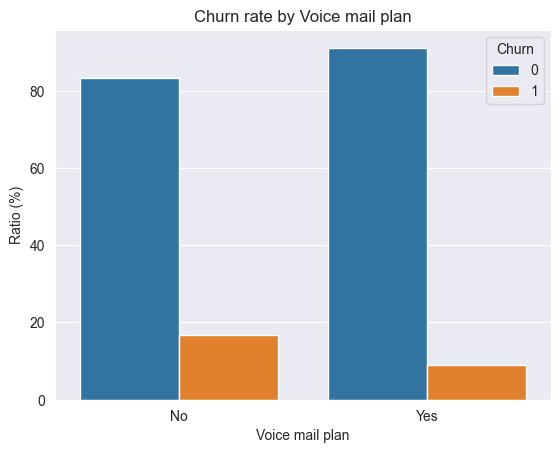

In [35]:
summary = df.groupby('Voice mail plan')['Churn'].value_counts().reset_index()
summary.columns = ['Voice mail plan', 'Churn', 'Count']
summary['Ratio'] = summary.groupby('Voice mail plan')['Count'].transform(lambda x: x / x.sum()) * 100
print(summary)
sns.barplot(data=summary, x='Voice mail plan', y='Ratio', hue='Churn')
plt.title('Churn rate by Voice mail plan')
plt.ylabel('Ratio (%)')
plt.show()



Nhận xét:
- Tỉ lệ churn có nhóm sử dụng thấp hơn nhóm k sử dụng tuy nhiên k đáng kể
- Số KH k dử dụng dịch vụ voice mail nhiều gấp 2.5 lần nhóm sử dụng
- Chênh lệch không quá lớn như International plan → feature này ít quan trọng hơn với model

Churn
0    100.0
1    103.0
Name: Account length, dtype: float64


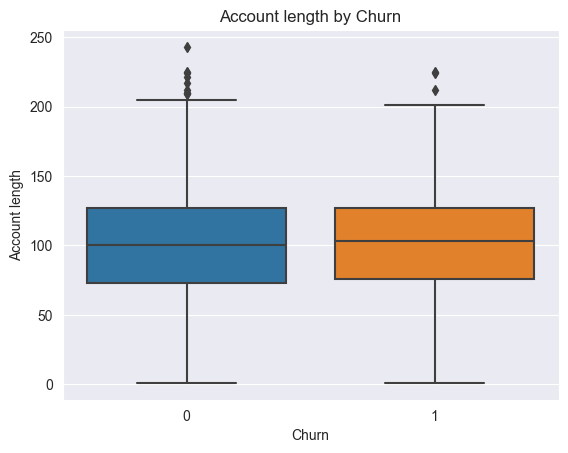

In [38]:
print(df.groupby('Churn')['Account length'].median())
sns.boxplot(data=df, x='Churn', y='Account length')
plt.title('Account length by Churn')
plt.show()

Churn
0    0.0
1    0.0
Name: Number vmail messages, dtype: float64


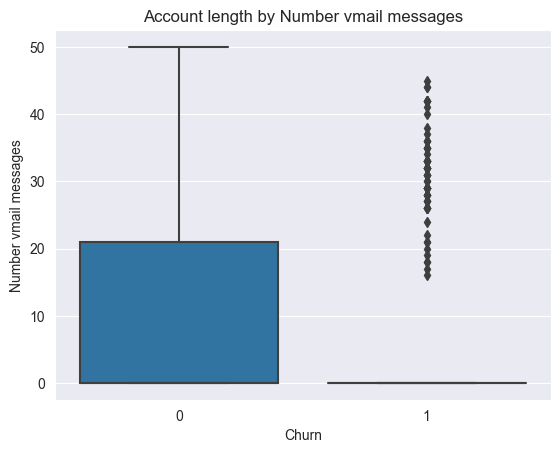

In [39]:
print(df.groupby('Churn')['Number vmail messages'].median())
sns.boxplot(data=df, x='Churn', y='Number vmail messages')
plt.title('Account length by Number vmail messages')
plt.show()

In [40]:
(df['Number vmail messages'] == 0).value_counts(normalize=True) * 100

Number vmail messages
True     72.505626
False    27.494374
Name: proportion, dtype: float64

Nhận xét:

- 72.5% khách có Number vmail messages = 0 → feature bị skewed nặng
- Median cả 2 nhóm churn/không churn đều = 0 → không phân tách được 2 nhóm
- Feature này redundant với Voice mail plan (không đăng ký plan thì messages tất nhiên = 0)
→ Có thể bỏ feature này khi train model

Churn
0    1.0
1    2.0
Name: Customer service calls, dtype: float64


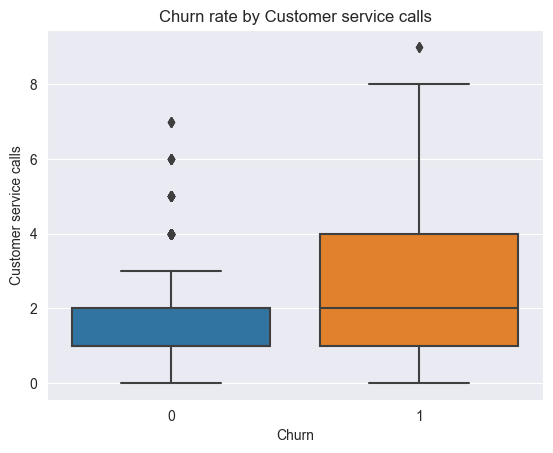

In [41]:
print(df.groupby('Churn')['Customer service calls'].median())
sns.boxplot(data=df, x='Churn', y='Customer service calls')
plt.title('Churn rate by Customer service calls')
plt.show()

  service_calls_bin  Churn  Count      Ratio
0               0-1      0   1322  88.133333
1               0-1      1    178  11.866667
2               2-4      0    926  85.032140
3               2-4      1    163  14.967860
4                5+      1     47  61.038961
5                5+      0     30  38.961039


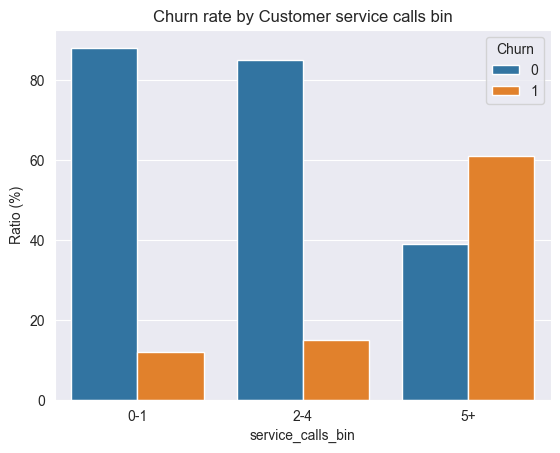

In [44]:
import warnings
warnings.filterwarnings('ignore')
bins = [0, 1, 4, float('inf')]
labels = ['0-1', '2-4', '5+']
df['service_calls_bin'] = pd.cut(df['Customer service calls'], bins=bins, labels=labels, include_lowest=True)

summary = df.groupby('service_calls_bin')['Churn'].value_counts().reset_index()
summary.columns = ['service_calls_bin', 'Churn', 'Count']
summary['Ratio'] = summary.groupby('service_calls_bin')['Count'].transform('sum')
summary['Ratio'] = summary['Count'] / summary['Ratio'] * 100
print(summary)

sns.barplot(data=summary, x='service_calls_bin', y='Ratio', hue='Churn')
plt.title('Churn rate by Customer service calls bin')
plt.ylabel('Ratio (%)')
plt.show()

Nhận xét:

- Nhóm 0-1 cuộc: churn chỉ ~12% → ít gọi CSKH thì hài lòng, ít rời đi
- Nhóm 2-4 cuộc: churn ~15% → tăng nhẹ, bắt đầu có dấu hiệu không hài lòng
- Nhóm 5+ cuộc: churn vọt lên 61% → gọi nhiều = rất không hài lòng, quá nửa rời đi

→ Feature rất quan trọng, tương quan rõ ràng: càng gọi nhiều CSKH càng dễ churn. Đây là signal mạnh cho model.

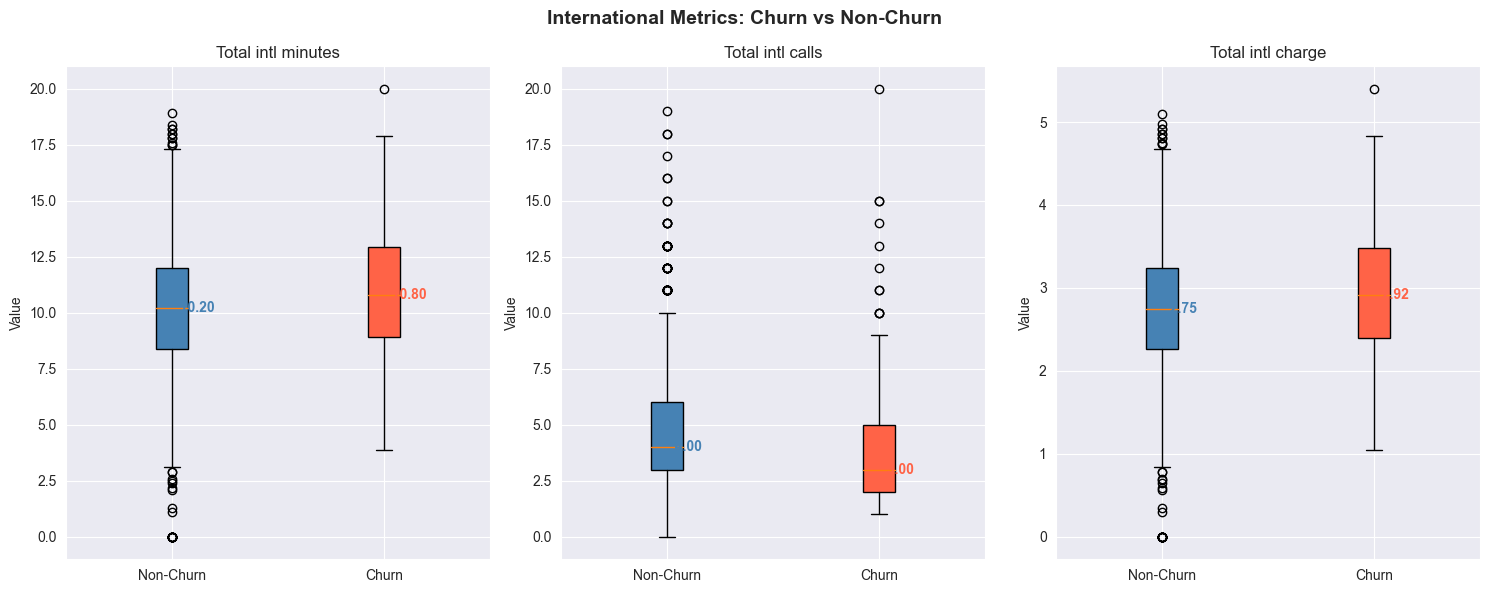

=== Median by Group ===

Total intl minutes:
  Non-Churn : 10.20
  Churn     : 10.80

Total intl calls:
  Non-Churn : 4.00
  Churn     : 3.00

Total intl charge:
  Non-Churn : 2.75
  Churn     : 2.92


In [46]:
import matplotlib.pyplot as plt

intl_cols = ['Total intl minutes', 'Total intl calls', 'Total intl charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(intl_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    # Hiện median lên plot luôn
    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.2f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.2f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('International Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('intl_boxplot.png', dpi=150)
plt.show()

# Print ra console luôn cho chắc
print("=== Median by Group ===")
for col in intl_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.2f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.2f}")

Nhóm Churn đang có một chút sự lưu ý:
- Total intl minutes: Non-Churn 10.20 vs Churn 10.80 — gần như không có khác biệt, 2 nhóm gọi quốc tế lượng tương đương nhau.
- Total intl calls: Non-Churn 4 vs Churn 3 — churn lại gọi ít cuộc hơn một chút, nhưng minutes lại cao hơn → tức là churn gọi ít cuộc nhưng mỗi cuộc dài hơn.
- Total intl charge: Non-Churn 2.75 vs Churn 2.92 — churn bị charge cao hơn, consistent với minutes cao hơn.
=> Các chỉ số quốc tế giữa 2 nhóm khá giống nhau, không có sự phân tách rõ ràng → feature này ít có khả năng là yếu tố chính ảnh hưởng đến churn trong dataset này.
- Cần có sự điều chỉnh linh hoạt hơn về giá, gọi cuộc hội thoại dài nên dc tối ưu hơn, đây là 1 business insight nên được thử để giữ chân khách hàng

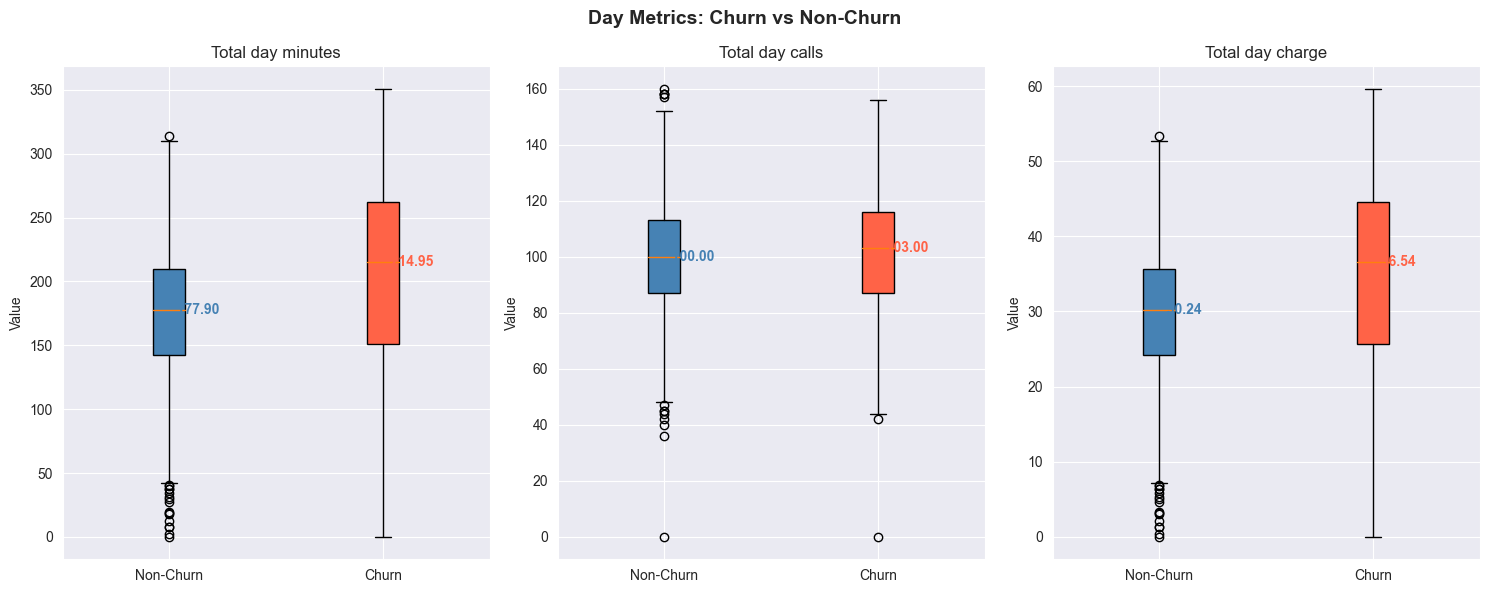

=== Median by Group ===

Total day minutes:
  Non-Churn : 177.90
  Churn     : 214.95

Total day calls:
  Non-Churn : 100.00
  Churn     : 103.00

Total day charge:
  Non-Churn : 30.24
  Churn     : 36.54


In [47]:
import matplotlib.pyplot as plt

day_cols = ['Total day minutes', 'Total day calls', 'Total day charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(day_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.2f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.2f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Day Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in day_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.2f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.2f}")

Nhận xét:
- Nhóm khách hàng Churn và non-churn k có sự chênh lệch nhiều về số cuộc gọi ban ngày, tuy nhiên số phút lại chênh khá nhiều khi churn sử dụng nhiều hơn 21% => chứng tỏ churn gọi nhiều và thời lượng cuộc gọi dài hơn, là heavy user.
- Chi phi cuộc gọi nhóm churn cũng cao hơn 20% => nhà mạng có thể nghiên cứu điều chỉnh gói cước sao gọi nhiều hơn, thời lượng lâu sẽ có ưu đãi hơn

In [48]:
df['day_charge_per_min'] = df['Total day charge'] / df['Total day minutes'].replace(0, pd.NA)  # giá mỗi phút
df['day_min_per_call'] = df['Total day minutes'] / df['Total day calls'].replace(0, pd.NA)      # thời lượng trung bình mỗi cuộc
df['day_charge_per_call'] = df['Total day charge'] / df['Total day calls'].replace(0, pd.NA)    # chi phí trung bình mỗi cuộc

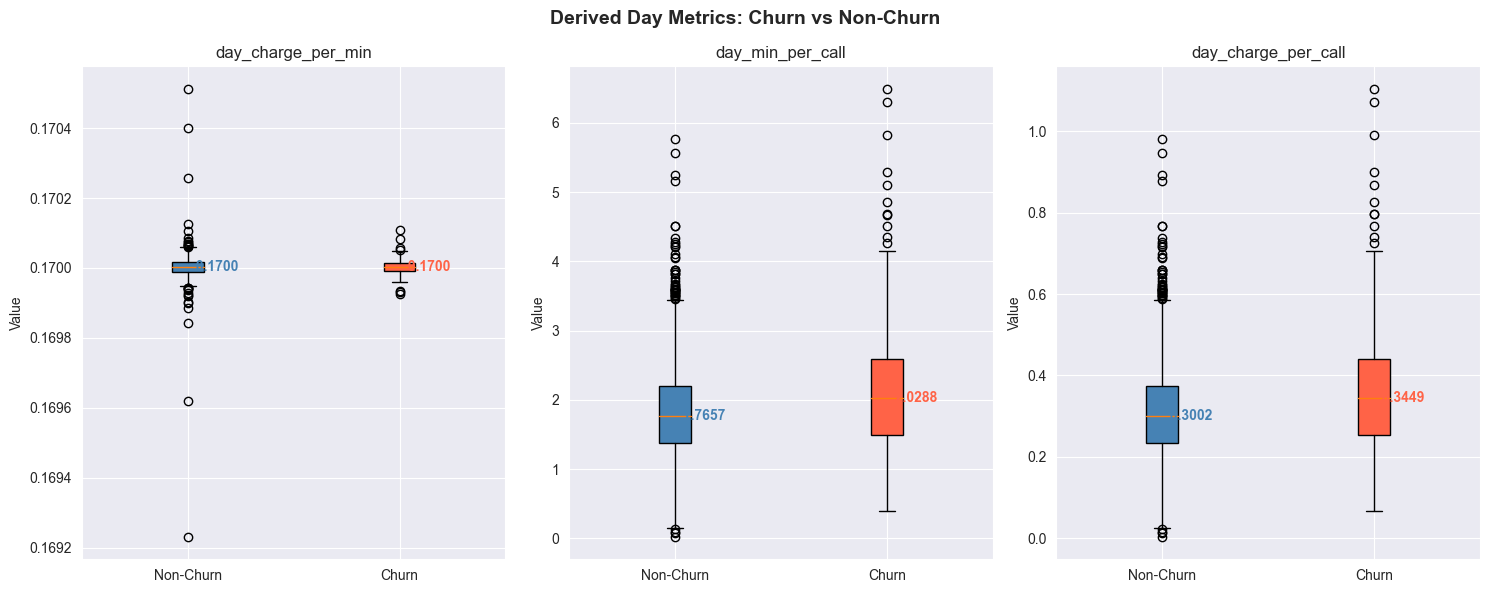

=== Median by Group ===

day_charge_per_min:
  Non-Churn : 0.1700
  Churn     : 0.1700

day_min_per_call:
  Non-Churn : 1.7657
  Churn     : 2.0288

day_charge_per_call:
  Non-Churn : 0.3002
  Churn     : 0.3449


In [49]:
new_cols = ['day_charge_per_min', 'day_min_per_call', 'day_charge_per_call']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(new_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.4f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.4f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Derived Day Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in new_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.4f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.4f}")

Nhận xét :
- day_charge_per_min: Cả 2 nhóm đều 0.1700 — hoàn toàn giống nhau → nhà mạng tính cùng một mức giá/phút cho tất cả khách, không có sự phân biệt. Feature này vô dụng với model.
- day_min_per_call: Non-Churn 1.77 vs Churn 2.03 — mỗi cuộc gọi của churn dài hơn ~15% → confirm lại insight trước, churn có hành vi gọi lâu hơn hẳn.
- day_charge_per_call: Non-Churn 0.30 vs Churn 0.34 — consistent với min_per_call, vì giá/phút như nhau nên cuộc dài hơn = tốn tiền hơn.


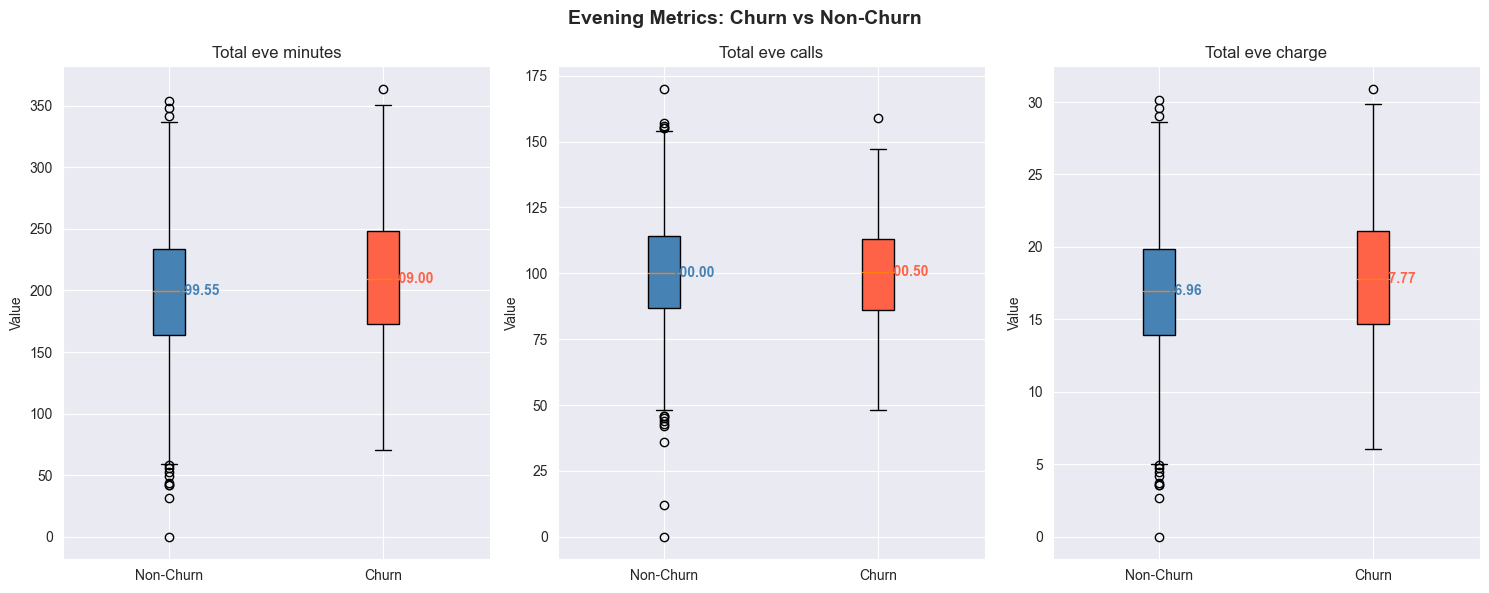

=== Median by Group ===

Total eve minutes:
  Non-Churn : 199.55
  Churn     : 209.00

Total eve calls:
  Non-Churn : 100.00
  Churn     : 100.50

Total eve charge:
  Non-Churn : 16.96
  Churn     : 17.77


In [50]:
import matplotlib.pyplot as plt

eve_cols = ['Total eve minutes', 'Total eve calls', 'Total eve charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(eve_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.2f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.2f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Evening Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in eve_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.2f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.2f}")

- Total eve minutes: Non-Churn 199.55 vs Churn 209.00, churn cao hơn 5%
- Total eve calls: Non-Churn 100 vs Churn 100.5 — gần như không khác biệt.
- Total eve charge: Non-Churn 16.96 vs Churn 17.77 — chênh ~5%, consistent với minutes.
=>  Eve metrics ít phân tách hơn day rõ ràng — hành vi buổi tối của 2 nhóm gần như tương đương nhau. Tín hiệu churn tập trung chủ yếu ở khung giờ ban ngày.


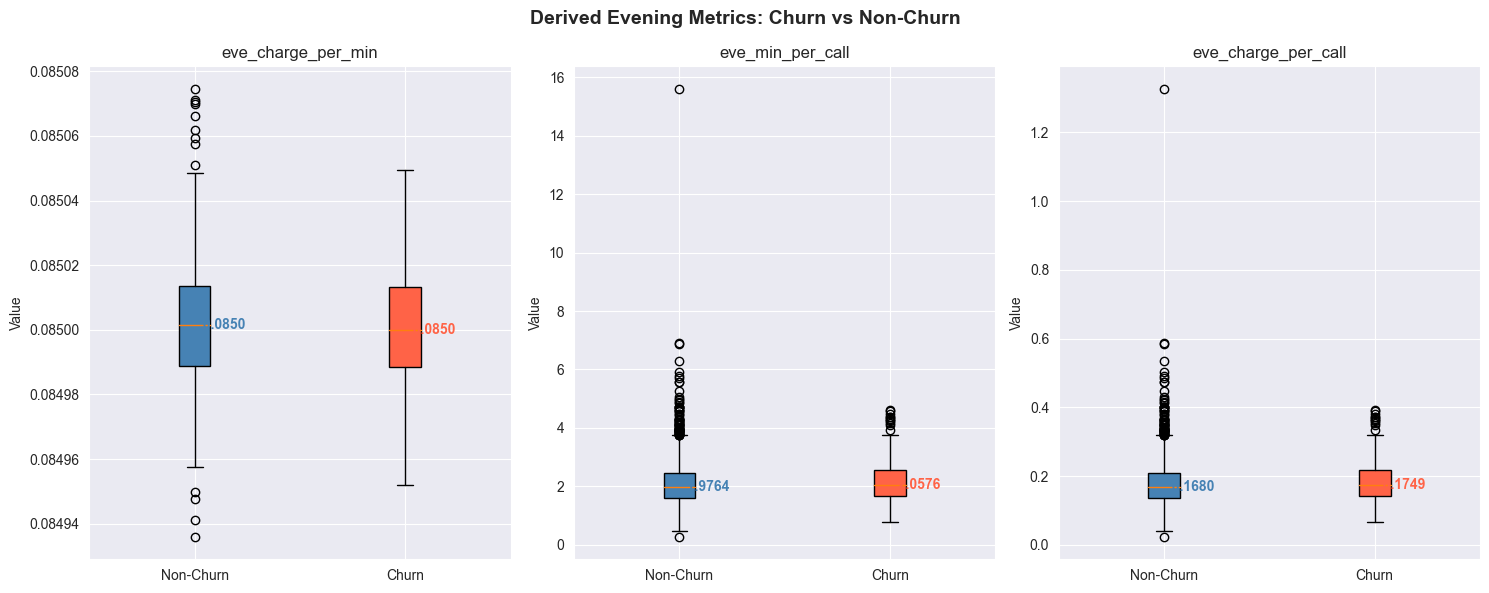

=== Median by Group ===

eve_charge_per_min:
  Non-Churn : 0.0850
  Churn     : 0.0850

eve_min_per_call:
  Non-Churn : 1.9764
  Churn     : 2.0576

eve_charge_per_call:
  Non-Churn : 0.1680
  Churn     : 0.1749


In [51]:
import matplotlib.pyplot as plt

# Tạo features
df['eve_charge_per_min'] = df['Total eve charge'] / df['Total eve minutes'].replace(0, pd.NA)
df['eve_min_per_call'] = df['Total eve minutes'] / df['Total eve calls'].replace(0, pd.NA)
df['eve_charge_per_call'] = df['Total eve charge'] / df['Total eve calls'].replace(0, pd.NA)

new_cols = ['eve_charge_per_min', 'eve_min_per_call', 'eve_charge_per_call']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(new_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.4f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.4f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Derived Evening Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in new_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.4f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.4f}")

Nhận xét:
- Gần như không phân tách dc ba chỉ số này ở thời điểm ban chiều
- eve_charge_per_min: 0.0850 vs 0.0850 — giống hệt, cùng tariff.
- eve_min_per_call: 1.9764 vs 2.0576 — chênh ~4% thôi, so với day là ~15%.
- eve_charge_per_call: 0.1680 vs 0.1749 — chênh ~4%, cũng rất nhỏ.

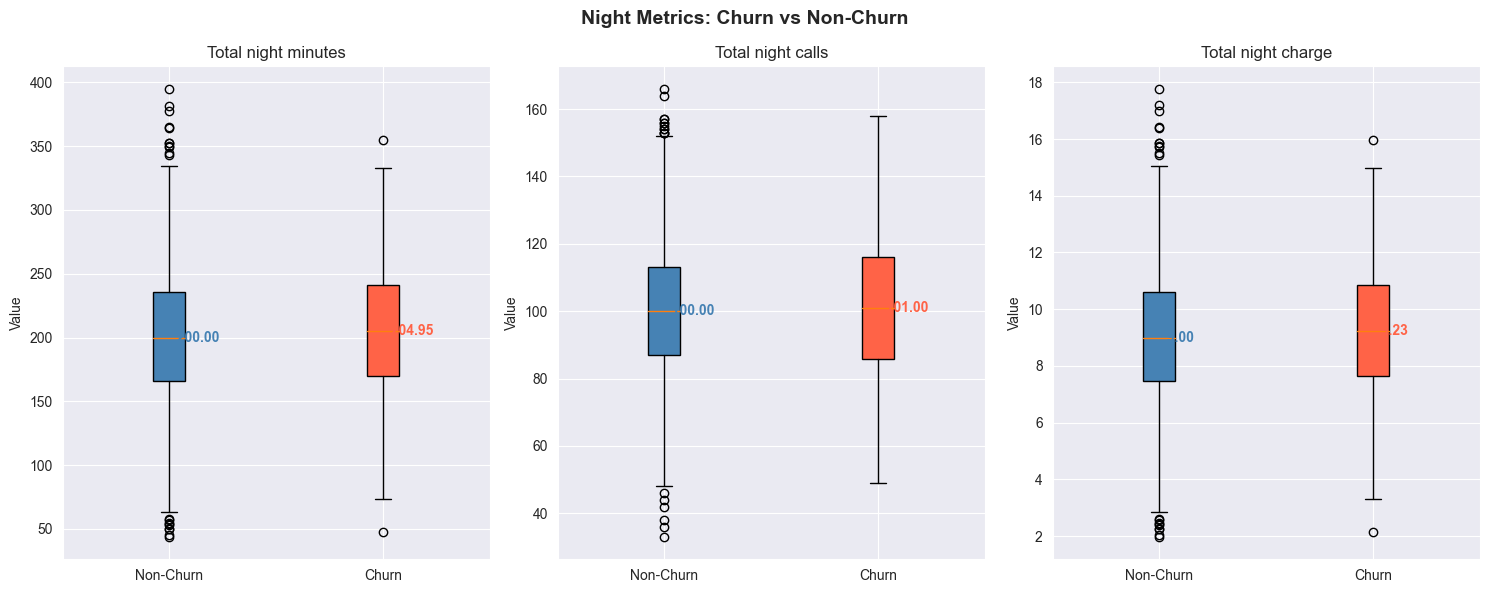

=== Median by Group ===

Total night minutes:
  Non-Churn : 200.00
  Churn     : 204.95

Total night calls:
  Non-Churn : 100.00
  Churn     : 101.00

Total night charge:
  Non-Churn : 9.00
  Churn     : 9.23


In [53]:
import matplotlib.pyplot as plt

night_cols = ['Total night minutes', 'Total night calls', 'Total night charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(night_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.2f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.2f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Night Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in night_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.2f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.2f}")


- Total night minutes: 200.00 vs 204.95 — chênh ~2.5%, gần như bằng nhau.
- Total night calls: 100 vs 101 — không khác biệt.
- Total night charge: 9.00 vs ~9.2x — chênh rất nhỏ, consistent với minutes.

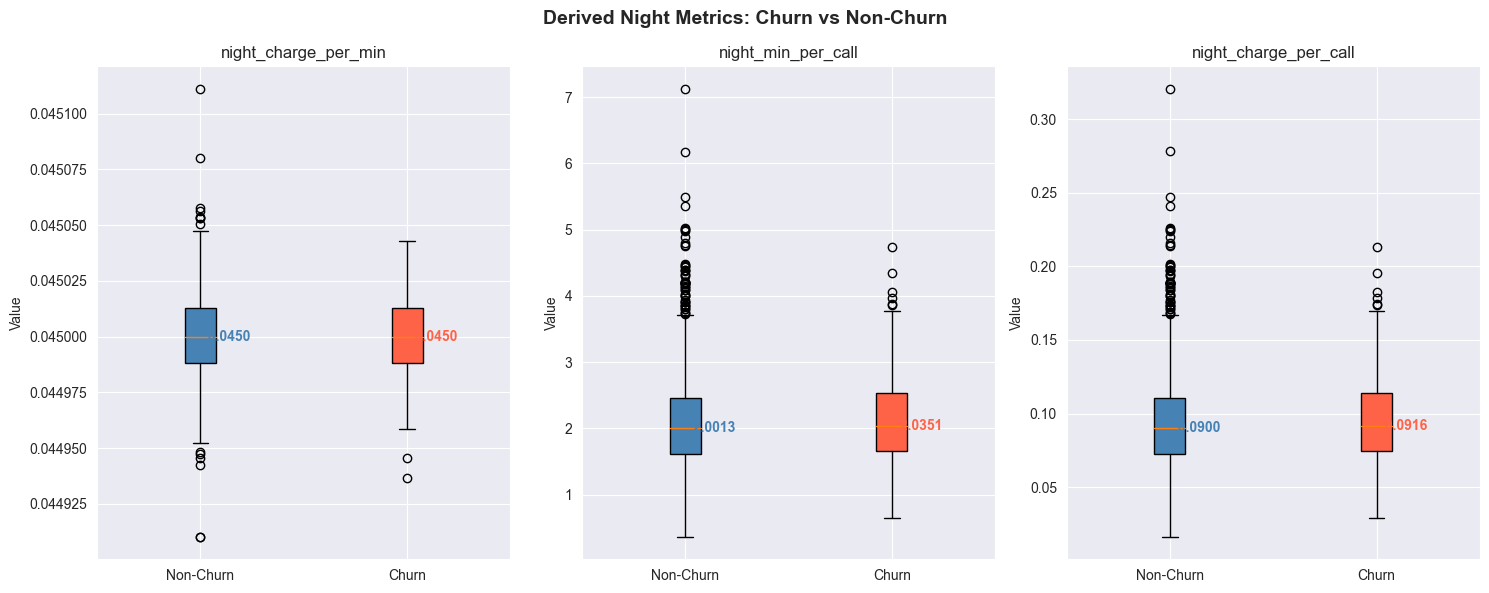

=== Median by Group ===

night_charge_per_min:
  Non-Churn : 0.0450
  Churn     : 0.0450

night_min_per_call:
  Non-Churn : 2.0013
  Churn     : 2.0351

night_charge_per_call:
  Non-Churn : 0.0900
  Churn     : 0.0916


In [54]:
import matplotlib.pyplot as plt

# Tạo features
df['night_charge_per_min'] = df['Total night charge'] / df['Total night minutes'].replace(0, pd.NA)
df['night_min_per_call'] = df['Total night minutes'] / df['Total night calls'].replace(0, pd.NA)
df['night_charge_per_call'] = df['Total night charge'] / df['Total night calls'].replace(0, pd.NA)

new_cols = ['night_charge_per_min', 'night_min_per_call', 'night_charge_per_call']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(new_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.4f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.4f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Derived Night Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in new_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.4f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.4f}")

Đúng như dự đoán, night derived metrics cũng gần như chưa tạo được sự khác biệt đáng kể:
- night_charge_per_min: 0.0450 vs 0.0450 — giống hệt, cùng tariff.
- night_min_per_call: 2.0013 vs 2.0351 — chênh ~1.7%, gần như không có gì.
- night_charge_per_call: 0.0900 vs 0.0916 — chênh ~1.8%, không đáng kể.



Phân tích hành vi cuộc gọi theo khung giờ: Churn vs Non-Churn
1. Khung giờ ban ngày (Day)
Đây là khung giờ có sự phân tách rõ ràng nhất giữa 2 nhóm. Nhóm Churn có tổng số phút gọi ban ngày cao hơn 21% so với Non-Churn, trong khi số cuộc gọi gần như tương đương. Điều này cho thấy nhóm Churn có xu hướng là heavy user, gọi ít cuộc hơn nhưng mỗi cuộc kéo dài hơn (15% theo day_min_per_call), dẫn đến chi phí ban ngày cao hơn 21%. Đây là tín hiệu quan trọng nhất trong toàn bộ phân tích cuộc gọi.
2. Khung giờ buổi tối (Evening)
Mức độ chênh lệch giảm đáng kể so với ban ngày. Tổng số phút gọi của nhóm Churn chỉ cao hơn 5%, số cuộc gọi gần như không khác biệt. Các derived features (eve_min_per_call, eve_charge_per_call) cũng chỉ chênh 4%, tín hiệu yếu, khó phân tách 2 nhóm.
3. Khung giờ ban đêm (Night)
Gần như không có sự khác biệt giữa 2 nhóm. Tổng phút gọi chênh 2.5%, night_min_per_call chênh chưa đến 2%. Cả 2 nhóm có hành vi gọi đêm tương đồng hoàn toàn.
4. Tổng kết: Tín hiệu churn tập trung chủ yếu ở khung giờ ban ngày, nhóm churn là heavy user ban ngày với chi phí cao hơn đáng kể. Eve và Night metrics không có khả năng phân tách và nên loại bỏ khỏi feature set của model.

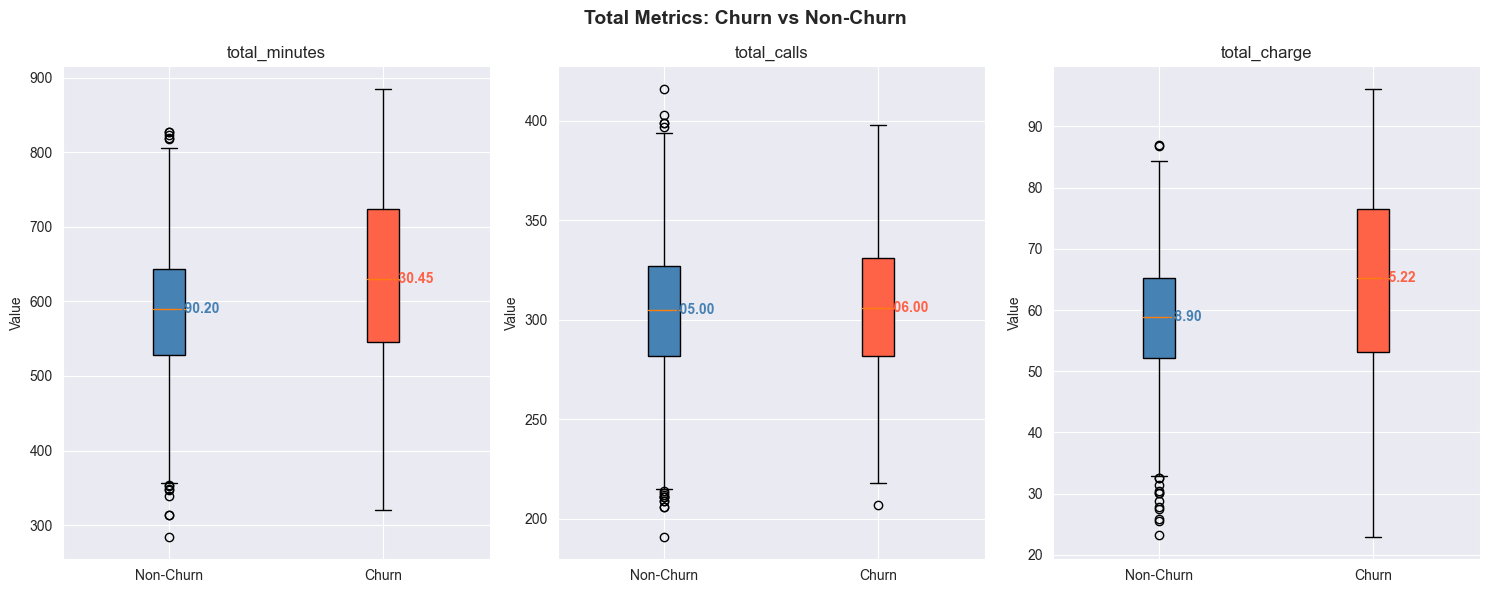

=== Median by Group ===

total_minutes:
  Non-Churn : 590.20
  Churn     : 630.45

total_calls:
  Non-Churn : 305.00
  Churn     : 306.00

total_charge:
  Non-Churn : 58.90
  Churn     : 65.22


In [55]:
import matplotlib.pyplot as plt

# Tạo features
df['total_minutes'] = df['Total day minutes'] + df['Total eve minutes'] + df['Total night minutes'] + df['Total intl minutes']
df['total_calls'] = df['Total day calls'] + df['Total eve calls'] + df['Total night calls'] + df['Total intl calls']
df['total_charge'] = df['Total day charge'] + df['Total eve charge'] + df['Total night charge'] + df['Total intl charge']

total_cols = ['total_minutes', 'total_calls', 'total_charge']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(total_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.2f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.2f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Total Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in total_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.2f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.2f}")

Nhận xét:
- Có sự khác biệt khá lớn về nhóm Churn và Non churn, khi số cuộc gọi gần như nhau, nhưng số phút của Churn thì cao đột biến kéo theo giá tiền tăng
- Như đã phân tích, giá tiền đang được áp dụng đều như nhau, chính vì vậy nhóm churn là nhóm heavy user hơn, họ nên dc xem xét lại giá cước, có thêm ưu đãi, đồng thời nhà mạng nên để ý thêm về chất lượng

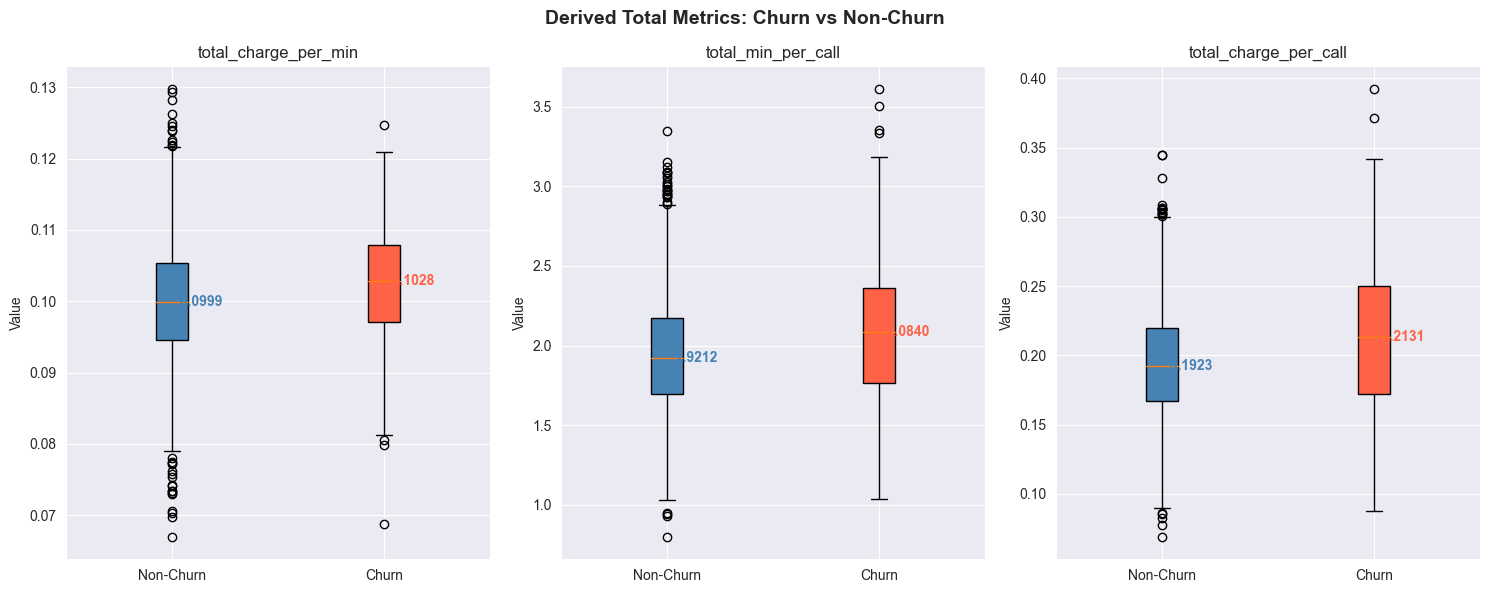

=== Median by Group ===

total_charge_per_min:
  Non-Churn : 0.0999
  Churn     : 0.1028

total_min_per_call:
  Non-Churn : 1.9212
  Churn     : 2.0840

total_charge_per_call:
  Non-Churn : 0.1923
  Churn     : 0.2131


In [56]:
import matplotlib.pyplot as plt

# Tạo features
df['total_charge_per_min'] = df['total_charge'] / df['total_minutes'].replace(0, pd.NA)
df['total_min_per_call'] = df['total_minutes'] / df['total_calls'].replace(0, pd.NA)
df['total_charge_per_call'] = df['total_charge'] / df['total_calls'].replace(0, pd.NA)

new_cols = ['total_charge_per_min', 'total_min_per_call', 'total_charge_per_call']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(new_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.4f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.4f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Derived Total Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in new_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.4f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.4f}")

Nhận xét:
- total_charge_per_min: 0.0999 vs 0.1028 — chênh ~3%, gần như không phân tách. Eve/night kéo giá/phút xuống làm mờ tín hiệu.
- total_min_per_call: 1.9212 vs 2.0840 — chênh ~8%
- total_charge_per_call: 0.1923 vs 0.2131 — chênh ~10%, tương tự.

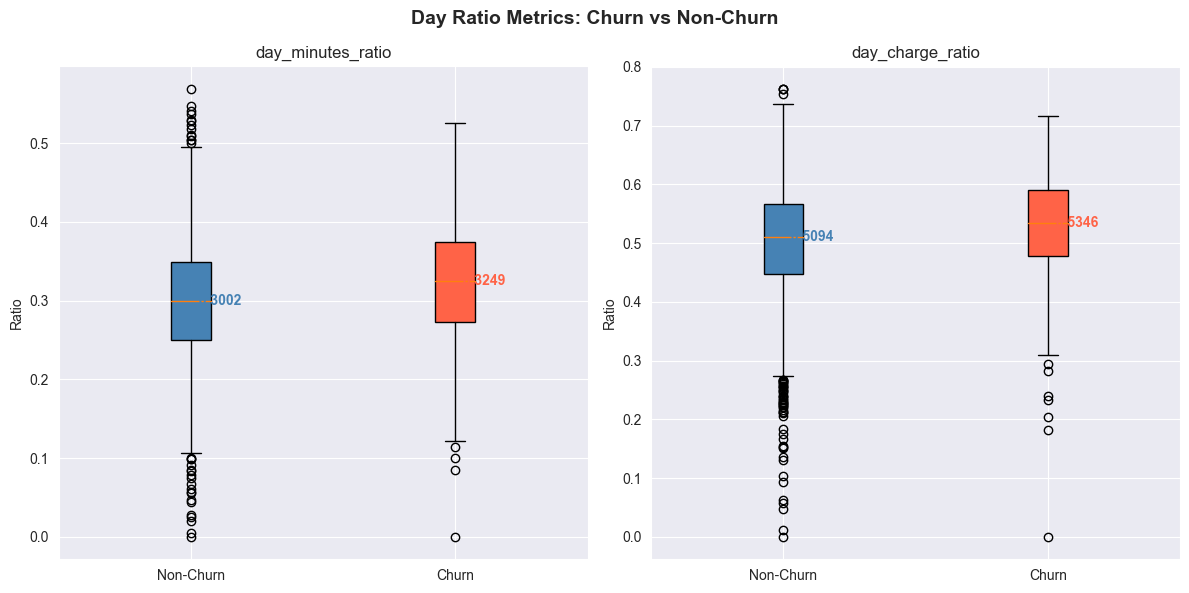

=== Median by Group ===

day_minutes_ratio:
  Non-Churn : 0.3002
  Churn     : 0.3249

day_charge_ratio:
  Non-Churn : 0.5094
  Churn     : 0.5346


In [58]:
import matplotlib.pyplot as plt

# Tạo features
df['day_minutes_ratio'] = df['Total day minutes'] / df['total_minutes']
df['day_charge_ratio'] = df['Total day charge'] / df['total_charge']

ratio_cols = ['day_minutes_ratio', 'day_charge_ratio']

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for i, col in enumerate(ratio_cols):
    non_churn = df[df['Churn'] == 0][col].dropna()
    churn = df[df['Churn'] == 1][col].dropna()

    bp = axes[i].boxplot([non_churn, churn], labels=['Non-Churn', 'Churn'], patch_artist=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(col)
    axes[i].set_ylabel('Ratio')

    med_non_churn = non_churn.median()
    med_churn = churn.median()
    axes[i].text(1, med_non_churn, f'  {med_non_churn:.4f}', va='center', fontsize=10, color='steelblue', fontweight='bold')
    axes[i].text(2, med_churn, f'  {med_churn:.4f}', va='center', fontsize=10, color='tomato', fontweight='bold')

plt.suptitle('Day Ratio Metrics: Churn vs Non-Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Median by Group ===")
for col in ratio_cols:
    print(f"\n{col}:")
    print(f"  Non-Churn : {df[df['Churn']==0][col].median():.4f}")
    print(f"  Churn     : {df[df['Churn']==1][col].median():.4f}")

In [59]:
from utils.helper import calc_iv_auc

feature_stats = calc_iv_auc(df)
print(feature_stats.to_string())

                   feature      iv     auc
0             total_charge  1.1582  0.6391
1        Total day minutes  0.6560  0.6334
2         Total day charge  0.6560  0.6334
3            total_minutes  0.5605  0.6252
4   Customer service calls  0.5330  0.5992
5    total_charge_per_call  0.3154  0.6129
6       total_min_per_call  0.1847  0.5980
7     total_charge_per_min  0.1393  0.5891
8        day_minutes_ratio  0.1178  0.5864
9         day_charge_ratio  0.0980  0.5816
10        Total eve charge  0.0944  0.5578
11       Total eve minutes  0.0931  0.5578
12       Total intl charge  0.0819  0.5657
13      Total intl minutes  0.0819  0.5657
14        Total intl calls  0.0800  0.5727
15    night_charge_per_min  0.0490  0.5057
16      Total night charge  0.0413  0.5265
17     Total night minutes  0.0392  0.5266
18       Total night calls  0.0302  0.5085
19         Total day calls  0.0292  0.5235
20             total_calls  0.0231  0.5127
21   Number vmail messages  0.0215  0.5593
22         